# Atividade 1

#### Evelyn Chiaperini e Betina Volpi

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# os import do humberto
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

# imports além dos do humberto
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import roc_auc_score

import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)  # avisos esperados da linha de base

# Semente fixa: garante que todos obtenham exatamente os mesmos resultados
SEED = 42
pd.set_option("display.max_columns", None)


In [43]:
# base de dados
df = pd.read_csv("bank_marketing_completo.csv")

## 1. Análise Exploratória


---



In [44]:
df.head(10)

,idade,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,duracao_ligacao_seg,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados,aderiu
0,56,empregado_domestico,casado,fundamental_4anos,nao,nao,nao,telefone_fixo,mai,seg,261,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
1,57,servicos,casado,ensino_medio,desconhecido,nao,nao,telefone_fixo,mai,seg,149,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
2,37,servicos,casado,ensino_medio,nao,sim,nao,telefone_fixo,mai,seg,226,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
3,40,administrativo,casado,fundamental_6anos,nao,nao,nao,telefone_fixo,mai,seg,151,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
4,56,servicos,casado,ensino_medio,nao,nao,sim,telefone_fixo,mai,seg,307,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
5,45,servicos,casado,fundamental_9anos,desconhecido,nao,nao,telefone_fixo,mai,seg,198,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
6,59,administrativo,casado,curso_profissionalizante,nao,nao,nao,telefone_fixo,mai,seg,139,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
7,41,operario,casado,desconhecido,desconhecido,nao,nao,telefone_fixo,mai,seg,217,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
8,24,tecnico,solteiro,curso_profissionalizante,nao,sim,nao,telefone_fixo,mai,seg,380,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
9,25,servicos,solteiro,ensino_medio,nao,sim,nao,telefone_fixo,mai,seg,50,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao


In [45]:
# Dimensões da base:
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

Linhas: 41188, Colunas: 21


In [46]:
# Tipos de dados:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idade                        41188 non-null  int64  
 1   profissao                    41188 non-null  object 
 2   estado_civil                 41188 non-null  object 
 3   escolaridade                 41188 non-null  object 
 4   inadimplente                 41188 non-null  object 
 5   financiamento_imobiliario    41188 non-null  object 
 6   emprestimo_pessoal           41188 non-null  object 
 7   meio_contato                 41188 non-null  object 
 8   mes                          41188 non-null  object 
 9   dia_semana                   41188 non-null  object 
 10  duracao_ligacao_seg          41188 non-null  int64  
 11  contatos_campanha_atual      41188 non-null  int64  
 12  dias_desde_ultimo_contato    41188 non-null  int64  
 13  contatos_anterio

,0
idade,int64
profissao,object
estado_civil,object
escolaridade,object
inadimplente,object
financiamento_imobiliario,object
emprestimo_pessoal,object
meio_contato,object
mes,object
dia_semana,object


In [47]:
# Distribuição da variável alvo em valores absolutos e percentuais

print("Absoluta:")
print(df['aderiu'].value_counts())

print("\nProporcional (%):")
print(f"{df['aderiu'].value_counts(normalize=True) * 100}")

Absoluta:
aderiu
nao    36548
sim     4640
Name: count, dtype: int64

Proporcional (%):
aderiu
nao    88.734583
sim    11.265417
Name: proportion, dtype: float64


In [48]:
# Nulos, duplicados e desconhecidos

# podem reduzir a qualidade dos dados, gerar informações repetidas ou exigir
# tratamento antes da modelagem, afetando o desempenho dos modelos

print(f"Valores nulos (NaN): {df.isnull().sum().sum()}")
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

desconhecidos = {}
for col in df.select_dtypes(include=['object']).columns:
    qtd = (df[col] == 'desconhecido').sum()
    if qtd > 0:
        pct = (qtd / len(df)) * 100
        desconhecidos[col] = [qtd, round(pct, 2)]

df_desconhecidos = pd.DataFrame(desconhecidos, index=['Quantidade', 'Porcentagem (%)']).T
print("\nFrequência do valor 'desconhecido' nas colunas categóricas:")
df_desconhecidos



Valores nulos (NaN): 0

Linhas duplicadas: 12

Frequência do valor 'desconhecido' nas colunas categóricas:


,Quantidade,Porcentagem (%)
profissao,330.0,0.80
estado_civil,80.0,0.19
escolaridade,1731.0,4.20
inadimplente,8597.0,20.87
financiamento_imobiliario,990.0,2.40
emprestimo_pessoal,990.0,2.40


In [49]:
# observando os valores duplicados

# keep=False traz todas as ocorrências das linhas que se repetem (24 linhas ao todo)
pares_duplicados = df[df.duplicated(keep=False)]

# Ordena por idade e profissão para ver os pares lado a lado no DataFrame
pares_duplicados.sort_values(by=['idade', 'profissao'])

,idade,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,duracao_ligacao_seg,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados,aderiu
28476,24,servicos,solteiro,ensino_medio,nao,sim,nao,celular,abr,ter,114,1,999,0,inexistente,-1.8,93.075,-47.1,1.423,5099.1,nao
28477,24,servicos,solteiro,ensino_medio,nao,sim,nao,celular,abr,ter,114,1,999,0,inexistente,-1.8,93.075,-47.1,1.423,5099.1,nao
14155,27,tecnico,solteiro,curso_profissionalizante,nao,nao,nao,celular,jul,seg,331,2,999,0,inexistente,1.4,93.918,-42.7,4.962,5228.1,nao
14234,27,tecnico,solteiro,curso_profissionalizante,nao,nao,nao,celular,jul,seg,331,2,999,0,inexistente,1.4,93.918,-42.7,4.962,5228.1,nao
18464,32,tecnico,solteiro,curso_profissionalizante,nao,sim,nao,celular,jul,qui,128,1,999,0,inexistente,1.4,93.918,-42.7,4.968,5228.1,nao
18465,32,tecnico,solteiro,curso_profissionalizante,nao,sim,nao,celular,jul,qui,128,1,999,0,inexistente,1.4,93.918,-42.7,4.968,5228.1,nao
32505,35,administrativo,casado,superior,nao,sim,nao,celular,mai,sex,348,4,999,0,inexistente,-1.8,92.893,-46.2,1.313,5099.1,nao
32516,35,administrativo,casado,superior,nao,sim,nao,celular,mai,sex,348,4,999,0,inexistente,-1.8,92.893,-46.2,1.313,5099.1,nao
12260,36,aposentado,casado,desconhecido,nao,nao,nao,telefone_fixo,jul,qui,88,1,999,0,inexistente,1.4,93.918,-42.7,4.966,5228.1,nao
12261,36,aposentado,casado,desconhecido,nao,nao,nao,telefone_fixo,jul,qui,88,1,999,0,inexistente,1.4,93.918,-42.7,4.966,5228.1,nao


In [50]:
# quantos clientes nunca foram contatados? (dias_desde_ultimo_contato = 999)

# Contagem direta utilizando comparação booleana
contagem_999 = (df['dias_desde_ultimo_contato'] == 999).value_counts()

# Renomeia os índices de True/False para facilitar a leitura
contagem_999.index = ['Nunca contatado (999)', 'Já contatado (!= 999)']
contagem_999

print(f"{(contagem_999/41188)*100}%")

Nunca contatado (999)    96.321744
Já contatado (!= 999)     3.678256
Name: count, dtype: float64%


In [51]:
# Acurácia do modelo ingênuo (prever sempre a classe majoritária 'nao')
acuracia_ingenuo = (df['aderiu'] == 'nao').mean() * 100
print(f"Acurácia do modelo que prevê apenas 'não': {acuracia_ingenuo:.2f}%")

Acurácia do modelo que prevê apenas 'não': 88.73%


Como 88,73% dos registros são da classe nao, prever sempre essa classe gera acurácia alta sem identificar nenhum cliente que aderiu. A acurácia isolada será insuficiente para avaliar os modelos

#### Visualizações que relacionam atributos à adesão

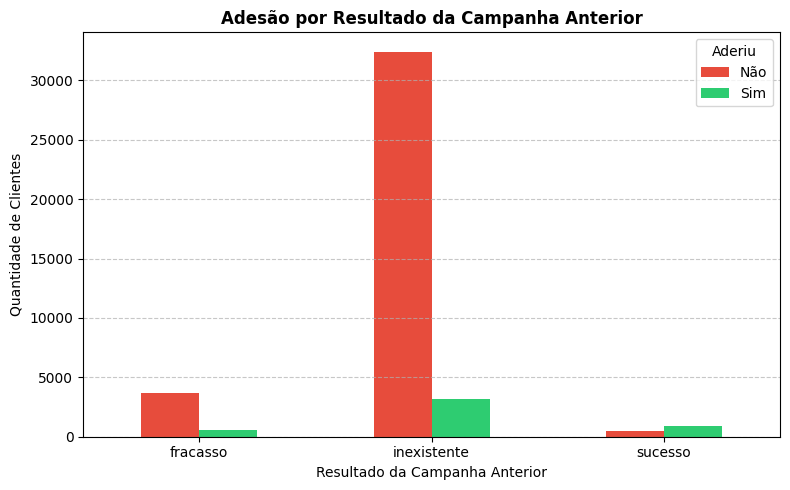

In [52]:
# Resultado Campanha Anterior vs Adesão
crosstab_res = pd.crosstab(df['resultado_campanha_anterior'], df['aderiu'])

# Plot do gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(8, 5))
crosstab_res[['nao', 'sim']].plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], rot=0)

ax.set_title('Adesão por Resultado da Campanha Anterior', fontsize=12, fontweight='bold')
ax.set_xlabel('Resultado da Campanha Anterior', fontsize=10)
ax.set_ylabel('Quantidade de Clientes', fontsize=10)
ax.legend(['Não', 'Sim'], title='Aderiu')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [53]:
# Tabela percentual por linha (dentro de cada histórico anterior, qual % aderiu)
pd.crosstab(df['resultado_campanha_anterior'], df['aderiu'], normalize='index') * 100

aderiu,nao,sim
resultado_campanha_anterior,,
fracasso,85.771402,14.228598
inexistente,91.167787,8.832213
sucesso,34.887109,65.112891


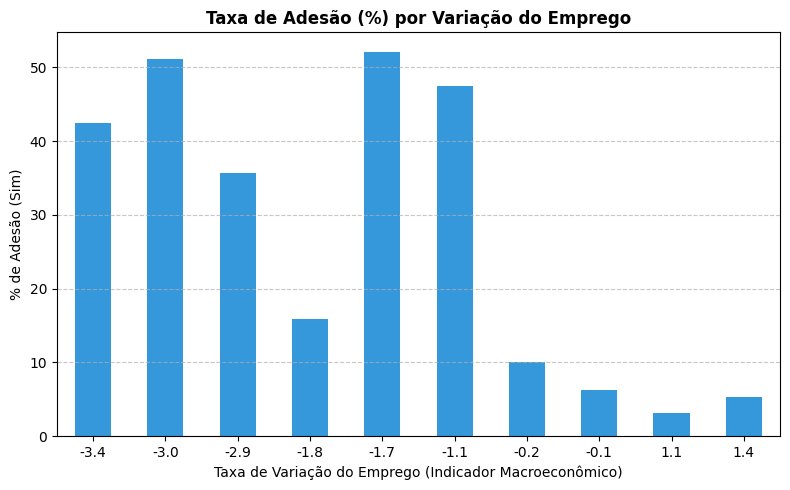

In [54]:
# Adesão (sim) vs Taxa de Variação de Emprego
prop_emp = df.groupby('taxa_variacao_emprego')['aderiu'].apply(lambda x: (x == 'sim').mean() * 100)

# Plot do gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))
prop_emp.plot(kind='bar', ax=ax, color='#3498db', rot=0)

ax.set_title('Taxa de Adesão (%) por Variação do Emprego', fontsize=12, fontweight='bold')
ax.set_xlabel('Taxa de Variação do Emprego (Indicador Macroeconômico)', fontsize=10)
ax.set_ylabel('% de Adesão (Sim)', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [55]:
# Taxa média de adesão para cada nível do indicador macroeconômico
df.groupby('taxa_variacao_emprego')['aderiu'].apply(lambda x: (x == 'sim').mean() * 100)

,aderiu
taxa_variacao_emprego,
-3.4,42.390289
-3.0,51.162791
-2.9,35.718581
-1.8,15.908101
-1.7,52.134541
-1.1,47.401575
-0.2,10.000000
-0.1,6.299213
1.1,3.091588


/tmp/ipykernel_39772/244533435.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_nao, data_sim], labels=['Não', 'Sim'], showfliers=False, patch_artist=True)


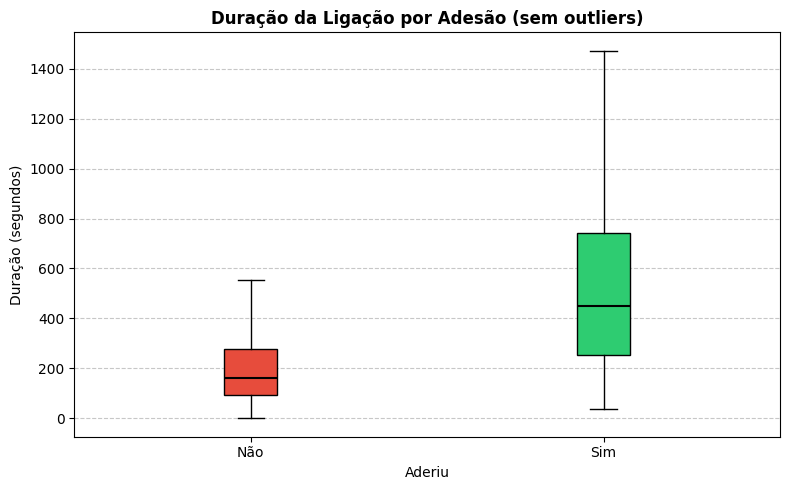

In [56]:
# Duração de Ligação vs Adesão

data_nao = df[df['aderiu'] == 'nao']['duracao_ligacao_seg']
data_sim = df[df['aderiu'] == 'sim']['duracao_ligacao_seg']

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([data_nao, data_sim], labels=['Não', 'Sim'], showfliers=False, patch_artist=True)

bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')
for median in bp['medians']:
    median.set(color='black', linewidth=1.5)

ax.set_title('Duração da Ligação por Adesão (sem outliers)', fontsize=12, fontweight='bold')
ax.set_xlabel('Aderiu', fontsize=10)
ax.set_ylabel('Duração (segundos)', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

A duração mediana foi de aproximadamente 450 segundos entre os que aderiram e 163 entre os que não aderiram. Ela é útil para explorar a base, mas só é conhecida após a ligação.

In [57]:
# Resumo estatístico (mediana e quartis) da duração por classe
df.groupby('aderiu')['duracao_ligacao_seg'].describe()

,count,mean,std,min,25%,50%,75%,max
aderiu,,,,,,,,
nao,36548.0,220.844807,207.096293,0.0,95.0,163.5,279.00,4918.0
sim,4640.0,553.191164,401.171871,37.0,253.0,449.0,741.25,4199.0


In [58]:
# Tabela de estatísticas dos outliers de duração por grupo
tb_outliers_duracao = df.groupby('aderiu')['duracao_ligacao_seg'].apply(
    lambda x: pd.Series({
        'Limite Corte (s)': x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)),
        'Qtd Outliers': (x > (x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))).sum(),
        'Mínimo Outlier (s)': x[x > (x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))].min(),
        'Mínimo Outlier (min)': round(x[x > (x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))].min() / 60, 2),
        'Máximo Outlier (s)': x[x > (x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))].max(),
        'Máximo Outlier (min)': round(x[x > (x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))].max() / 60, 2)
    })
).unstack()

# Organizando os nomes dos índices para exibição
tb_outliers_duracao.index = ['Não', 'Sim']
tb_outliers_duracao.index.name = 'Aderiu'

print("=== TABELA: ESTATÍSTICAS DOS OUTLIERS DE DURAÇÃO POR GRUPO ===")
tb_outliers_duracao

=== TABELA: ESTATÍSTICAS DOS OUTLIERS DE DURAÇÃO POR GRUPO ===


,Limite Corte (s),Qtd Outliers,Mínimo Outlier (s),Mínimo Outlier (min),Máximo Outlier (s),Máximo Outlier (min)
Aderiu,,,,,,
Não,555.000,2179.0,556.0,9.27,4918.0,81.97
Sim,1473.625,138.0,1479.0,24.65,4199.0,69.98


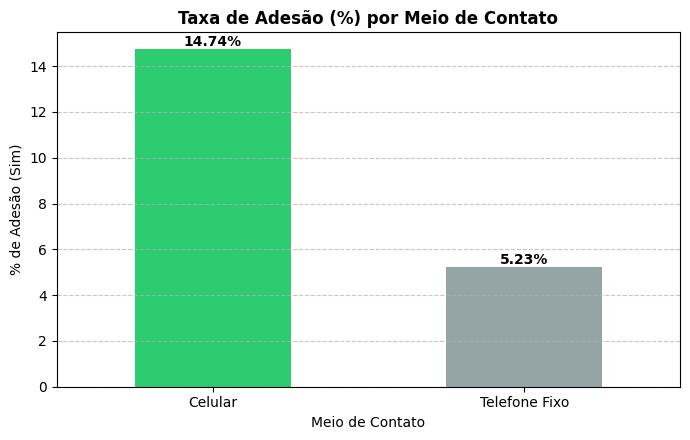

In [59]:
# Taxa de Adesão (%) por Meio de Contato

# Cálculo do percentual de adesão por meio de contato
prop_contato = df.groupby('meio_contato')['aderiu'].apply(lambda x: (x == 'sim').mean() * 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
prop_contato.plot(kind='bar', ax=ax, color=['#2ecc71', '#95a5a6'], rot=0)

ax.set_title('Taxa de Adesão (%) por Meio de Contato', fontsize=12, fontweight='bold')
ax.set_xlabel('Meio de Contato', fontsize=10)
ax.set_ylabel('% de Adesão (Sim)', fontsize=10)
ax.set_xticklabels(['Celular', 'Telefone Fixo'])
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar rótulos de porcentagem em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

In [60]:
# Tabela cruzada de contagem absoluta e taxa de conversão percentual
ct_contato = pd.crosstab(df['meio_contato'], df['aderiu'], margins=True, margins_name='Total')
pct_contato = pd.crosstab(df['meio_contato'], df['aderiu'], normalize='index') * 100

# Consolidando em um DataFrame formatado
tb_meio_contato = pd.DataFrame({
    'Não Aderiu (Qtd)': ct_contato['nao'].drop('Total'),
    'Aderiu (Qtd)': ct_contato['sim'].drop('Total'),
    'Total de Contatos': ct_contato['Total'].drop('Total'),
    'Taxa de Adesão (%)': pct_contato['sim'].round(2)
})

print("=== TABELA: DESEMPENHO POR MEIO DE CONTATO ===")
tb_meio_contato

=== TABELA: DESEMPENHO POR MEIO DE CONTATO ===


,Não Aderiu (Qtd),Aderiu (Qtd),Total de Contatos,Taxa de Adesão (%)
meio_contato,,,,
celular,22291,3853,26144,14.74
telefone_fixo,14257,787,15044,5.23


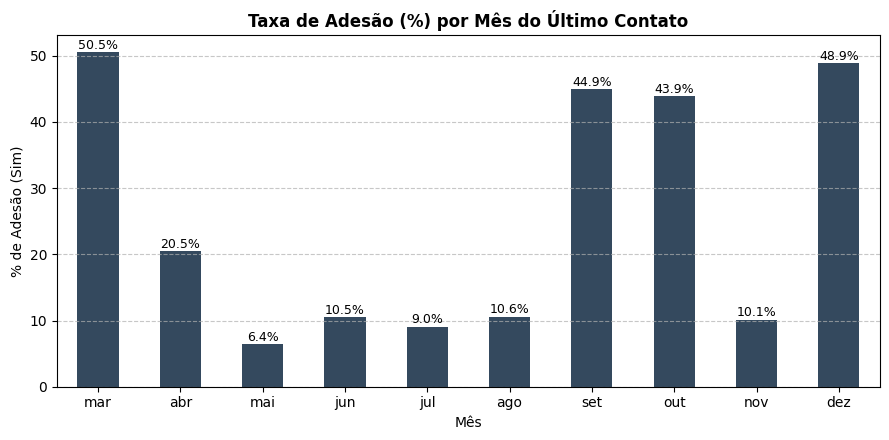

In [61]:
# Taxa de Adesão (%) por Mês do Contato
# Ordenar os meses cronologicamente para exibição
ordem_meses = ['mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']
prop_mes = df.groupby('mes')['aderiu'].apply(lambda x: (x == 'sim').mean() * 100).loc[ordem_meses]

fig, ax = plt.subplots(figsize=(9, 4.5))
prop_mes.plot(kind='bar', ax=ax, color='#34495e', rot=0)

ax.set_title('Taxa de Adesão (%) por Mês do Último Contato', fontsize=12, fontweight='bold')
ax.set_xlabel('Mês', fontsize=10)
ax.set_ylabel('% de Adesão (Sim)', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar rótulos de porcentagem
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

In [62]:
# Ordem cronológica dos meses no dataset
ordem_meses = ['mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']

# Tabela cruzada reordenada cronologicamente
ct_mes = pd.crosstab(df['mes'], df['aderiu'], margins=True, margins_name='Total').reindex(ordem_meses)
pct_mes = pd.crosstab(df['mes'], df['aderiu'], normalize='index').reindex(ordem_meses) * 100

# Consolidando em um DataFrame formatado
tb_mes = pd.DataFrame({
    'Não Aderiu (Qtd)': ct_mes['nao'],
    'Aderiu (Qtd)': ct_mes['sim'],
    'Total de Contatos': ct_mes['Total'],
    'Taxa de Adesão (%)': pct_mes['sim'].round(2)
})

print("=== TABELA: DESEMPENHO POR MÊS DO ÚLTIMO CONTATO ===")
tb_mes

=== TABELA: DESEMPENHO POR MÊS DO ÚLTIMO CONTATO ===


,Não Aderiu (Qtd),Aderiu (Qtd),Total de Contatos,Taxa de Adesão (%)
mes,,,,
mar,270,276,546,50.55
abr,2093,539,2632,20.48
mai,12883,886,13769,6.43
jun,4759,559,5318,10.51
jul,6525,649,7174,9.05
ago,5523,655,6178,10.60
set,314,256,570,44.91
out,403,315,718,43.87
nov,3685,416,4101,10.14


### Correlação

In [63]:
# 1. Mapear a variável-alvo 'aderiu' para formato numérico (sim = 1, nao = 0)
df_cat = df.copy()
df_cat['aderiu_num'] = (df_cat['aderiu'] == 'sim').astype(int)

# 2. Selecionar colunas categóricas e aplicar One-Hot Encoding
colunas_categoricas = df_cat.select_dtypes(include=['object']).columns.drop('aderiu')
df_cat_encoded = pd.get_dummies(df_cat[colunas_categoricas], drop_first=False)
df_cat_encoded['aderiu_num'] = df_cat['aderiu_num']

# 3. Calcular a correlação com a classe alvo
corr_cat = df_cat_encoded.corr()['aderiu_num'].drop('aderiu_num').sort_values(ascending=False)

# 4. DataFrame formatado
df_corr_categoricas = pd.DataFrame({
    'Categoria': corr_cat.index,
    'Correlação com Adesão': corr_cat.values.round(4)
}).reset_index(drop=True)

# 5. Filtrar se existe alguma correlação forte (|r| >= 0.7)
fortes_cat = df_corr_categoricas[df_corr_categoricas['Correlação com Adesão'].abs() >= 0.7]

print("=== CORRELAÇÃO DE TODAS AS CATEGORIAS COM A ADESÃO ('aderiu') ===")
display(df_corr_categoricas)

print("\n--- AVALIAÇÃO DE REGRA DE CORRELAÇÃO FORTE (|r| >= 0.70) ---")
if len(fortes_cat) == 0:
    print("Nenhuma categoria isolada possui correlação forte (>= 0.70 ou <= -0.70) com a adesão.")
else:
    print("Categorias com correlação forte encontradas:")
    display(fortes_cat)

=== CORRELAÇÃO DE TODAS AS CATEGORIAS COM A ADESÃO ('aderiu') ===


,Categoria,Correlação com Adesão
0,resultado_campanha_anterior_sucesso,0.3163
1,meio_contato_celular,0.1448
2,mes_mar,0.1440
3,mes_out,0.1374
4,mes_set,0.1261
5,inadimplente_nao,0.0993
6,profissao_estudante,0.0940
7,profissao_aposentado,0.0922
8,mes_dez,0.0793
9,mes_abr,0.0761



--- AVALIAÇÃO DE REGRA DE CORRELAÇÃO FORTE (|r| >= 0.70) ---
Nenhuma categoria isolada possui correlação forte (>= 0.70 ou <= -0.70) com a adesão.


As correlações resumem associações individuais com a adesão. Elas complementam os gráficos, mas não indicam causalidade nem determinam, sozinhas, quais atributos usar.

In [64]:
# 1. Mapear a variável-alvo 'aderiu' para formato numérico (sim = 1, nao = 0)
df_num = df.copy()
df_num['aderiu_num'] = (df_num['aderiu'] == 'sim').astype(int)

# 2. Selecionar colunas numéricas
colunas_numericas = df_num.select_dtypes(include=[np.number]).columns.drop('aderiu_num')

# 3. Calcular a correlação com a classe alvo
corr_num = df_num[colunas_numericas].corrwith(df_num['aderiu_num']).sort_values(ascending=False)

# 4. DataFrame formatado
df_corr_numericas = pd.DataFrame({
    'Atributo Numérico': corr_num.index,
    'Correlação com Adesão': corr_num.values.round(4)
}).reset_index(drop=True)

# 5. Filtrar se existe alguma correlação forte (|r| >= 0.7)
fortes_num = df_corr_numericas[df_corr_numericas['Correlação com Adesão'].abs() >= 0.7]

print("=== CORRELAÇÃO DE TODAS AS VARIÁVEIS NUMÉRICAS COM A ADESÃO ('aderiu') ===")
display(df_corr_numericas)

print("\n--- AVALIAÇÃO DE REGRA DE CORRELAÇÃO FORTE (|r| >= 0.70) ---")
if len(fortes_num) == 0:
    print("Nenhuma variável numérica possui correlação forte (>= 0.70 ou <= -0.70) com a adesão.")
else:
    print("Variáveis numéricas com correlação forte encontradas:")
    display(fortes_num)

=== CORRELAÇÃO DE TODAS AS VARIÁVEIS NUMÉRICAS COM A ADESÃO ('aderiu') ===


,Atributo Numérico,Correlação com Adesão
0,duracao_ligacao_seg,0.4053
1,contatos_anteriores,0.2302
2,indice_confianca_consumidor,0.0549
3,idade,0.0304
4,contatos_campanha_atual,-0.0664
5,indice_precos_consumidor,-0.1362
6,taxa_variacao_emprego,-0.2983
7,euribor_3m,-0.3078
8,dias_desde_ultimo_contato,-0.3249
9,numero_empregados,-0.3547



--- AVALIAÇÃO DE REGRA DE CORRELAÇÃO FORTE (|r| >= 0.70) ---
Nenhuma variável numérica possui correlação forte (>= 0.70 ou <= -0.70) com a adesão.


A base não possui valores nulos, mas contém 12 linhas duplicadas, categorias “desconhecido” e o código 999 para ausência de contato anterior. A adesão é minoritária (11,27%), por isso a acurácia isolada pode ser enganosa. Histórico de campanhas, contexto econômico, meio de contato e mês apresentam associações com a adesão. A duração da ligação também apresenta associação, mas só é conhecida após o contato e não deve entrar na previsão prévia.

## 2. Preparação dos Dados


---



In [65]:
# Remoção de instâncias idênticas para evitar viés de sobre-representação e overfitting nas etapas de treino e teste.
df = df.drop_duplicates()

In [66]:
df['contatado_anteriormente'] = (df['dias_desde_ultimo_contato'] != 999).astype(int)

df['dias_desde_ultimo_contato_clean'] = df['dias_desde_ultimo_contato'].replace(999, -1)

df = df.drop(columns=['dias_desde_ultimo_contato'])

print("=== FEATURE ENGINEERING CONCLUÍDA ===")
print(df[['contatado_anteriormente', 'dias_desde_ultimo_contato_clean']].head())

=== FEATURE ENGINEERING CONCLUÍDA ===
   contatado_anteriormente  dias_desde_ultimo_contato_clean
0                        0                               -1
1                        0                               -1
2                        0                               -1
3                        0                               -1
4                        0                               -1


O valor 999 significa ausência de contato anterior -> criamos um indicador para distinguir esse caso de uma quantidade real de dias.

In [67]:
# mapeamento da variavel-alvo (Aderiu) para binário (1 e 0)
mapeamento_target = {
    'nao': 0,
    'sim': 1
}

df['aderiu'] = df['aderiu'].astype(str).str.strip().str.lower().map(mapeamento_target)

print("Distribuição das classes na variável 'aderiu':")
print(df['aderiu'].value_counts(normalize=False))
print("\nProporção das classes (%):")
print(df['aderiu'].value_counts(normalize=True) * 100)

Distribuição das classes na variável 'aderiu':
aderiu
0    36537
1     4639
Name: count, dtype: int64

Proporção das classes (%):
aderiu
0    88.733728
1    11.266272
Name: proportion, dtype: float64


In [68]:
# One-Hot Encoding para variáveis categóricas nominais, mantendo a categoria 'unknown' como uma informação explícita para o modelo.
colunas_categoricas = [
    'profissao', 'estado_civil', 'escolaridade',
    'inadimplente', 'financiamento_imobiliario',
    'emprestimo_pessoal', 'meio_contato', 'mes', 'dia_semana',
    'resultado_campanha_anterior'
]

df_encoded = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

In [69]:
# Guardar os atributos antes de excluir a duração do cenário principal.
df_cenario_completo = df.copy()

In [70]:
# remoção da duracao da ligação

df = df.drop(columns=['duracao_ligacao_seg'])

In [71]:
# divisão de treino e teste

# 1. Separação de Atributos e Target
X = df.drop(columns=['aderiu'])
y = df['aderiu']

# 2. Split Treino (70%) e Teste (30%) com estratificação para manter a proporção do target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Treino (X_train): {X_train.shape}")
print(f"Teste (X_test):   {X_test.shape}")

Treino (X_train): (28823, 20)
Teste (X_test):   (12353, 20)


In [72]:
# 1. Pipeline Numérico
pipe_num = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escala', StandardScaler())
])

# 2. Pipeline Categórico
pipe_cat = Pipeline([
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# 3. ColumnTransformer
preparacao = ColumnTransformer([
    ('num', pipe_num, num_cols),
    ('cat', pipe_cat, cat_cols)
])

# # 4. Pipeline Final Unificado com Estimador
# modelo_completo = Pipeline([
#     ('preparacao', preparacao),
#     ('modelo', LogisticRegression(max_iter=1000, random_state=42))
# ])

# # 5. Treinamento e Avaliação
# modelo_completo.fit(X_train, y_train)
# y_pred = modelo_completo.predict(X_test)

# print(f"Acurácia no Teste: {accuracy_score(y_test, y_pred):.4f}")
# print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

## 3. Modelagem


---



### K-NN

In [73]:
# amostragem estratificada e gridsearchcv

# 1. Amostragem estratificada do treino para a busca de hiperparâmetros (30% do treino)
# Justificativa: O algoritmo k-NN possui alto custo computacional O(N * d) na fase de inferência.
# A amostragem preserva a proporção da classe 'aderiu' e acelera a validação cruzada.
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train,
    train_size=0.3,
    random_state=42,
    stratify=y_train
)

# 2. Definição do Pipeline unificado do k-NN
pipeline_knn = Pipeline([
    ('preparacao', preparacao),
    ('knn', KNeighborsClassifier())
])

# 3. Grade de hiperparâmetros para busca do valor de k (ímpares para evitar empates)
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance']
}

# 4. Validação Cruzada Estratificada (5-Fold)
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configuração do GridSearch avaliando por ROC-AUC (recomendado para classes desbalanceadas)
grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    cv=cv_stratified,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Execução da busca sobre a amostra estratificada
grid_knn.fit(X_train_sub, y_train_sub)

print(f"Melhor valor de k encontrado: {grid_knn.best_params_['knn__n_neighbors']}")
print(f"Melhor peso de vizinhos: {grid_knn.best_params_['knn__weights']}")
print(f"Melhor ROC-AUC na Validação Cruzada: {grid_knn.best_score_:.4f}")

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Melhor valor de k encontrado: 21
Melhor peso de vizinhos: uniform
Melhor ROC-AUC na Validação Cruzada: 0.7557


--- DESEMPENHO DO k-NN NO CONJUNTO DE TESTE ---
Acurácia: 0.8990
ROC-AUC:   0.7823

Matriz de Confusão:


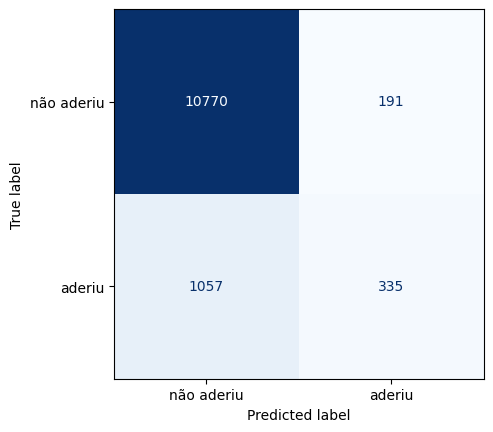


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95     10961
           1       0.64      0.24      0.35      1392

    accuracy                           0.90     12353
   macro avg       0.77      0.61      0.65     12353
weighted avg       0.88      0.90      0.88     12353



In [74]:
# treinamento do modelo

# 1. Instanciar o Pipeline final com os melhores hiperparâmetros encontrados
melhor_k = grid_knn.best_params_['knn__n_neighbors']
melhor_peso = grid_knn.best_params_['knn__weights']

modelo_knn_final = Pipeline([
    ('preparacao', preparacao),
    ('knn', KNeighborsClassifier(n_neighbors=melhor_k, weights=melhor_peso))
])

# 2. Treinar o modelo final sobre o CONJUNTO DE TREINO COMPLETO (X_train)
modelo_knn_final.fit(X_train, y_train)

# 3. Predições no conjunto de teste (X_test)
y_pred_knn = modelo_knn_final.predict(X_test)
y_proba_knn = modelo_knn_final.predict_proba(X_test)[:, 1]

# 4. Avaliação de desempenho no Teste
print("--- DESEMPENHO DO k-NN NO CONJUNTO DE TESTE ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_knn):.4f}\n")
cm = confusion_matrix(y_test, y_pred_knn)
print("Matriz de Confusão:")
ConfusionMatrixDisplay(cm, display_labels=["não aderiu", "aderiu"]).plot(
  cmap="Blues", colorbar=False)
plt.show()
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_knn))

### Naive Bayes

In [75]:
# 1. Pipeline para GaussianNB (Numéricas Padronizadas + Categóricas One-Hot)
preparacao_gnb = ColumnTransformer([
    ('num', Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escala', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

modelo_gnb = Pipeline([
    ('preparacao', preparacao_gnb),
    ('gnb', GaussianNB())
])

In [76]:
# 2. Pipeline para BernoulliNB (Trata atributos como indicadores binários)
modelo_bnb = Pipeline([
    ('preparacao', preparacao_gnb), # Aproveita a mesma estrutura binarizada pelo One-Hot
    ('bnb', BernoulliNB(binarize=0.0)) # Binariza numéricas padronizadas em z > 0 (1) e z <= 0 (0)
])

In [77]:
# Validação Cruzada Estratificada para comparar a ROC-AUC das duas variantes no treino
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_gnb = cross_val_score(modelo_gnb, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
scores_bnb = cross_val_score(modelo_bnb, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print("=== VALIDAÇÃO CRUZADA (ROC-AUC Média) ===")
print(f"1. GaussianNB:  {scores_gnb.mean():.4f} (+/- {scores_gnb.std():.4f})")
print(f"2. BernoulliNB: {scores_bnb.mean():.4f} (+/- {scores_bnb.std():.4f})")

=== VALIDAÇÃO CRUZADA (ROC-AUC Média) ===
1. GaussianNB:  0.7626 (+/- 0.0133)
2. BernoulliNB: 0.7652 (+/- 0.0128)


Escolhemos BernoulliNB para a comparação final porque ele trabalha com os indicadores binários produzidos pela codificação e teve ROC-AUC média ligeiramente maior na validação do treino (0,7652 contra 0,7626 da GaussianNB).

In [78]:
# Treinar ambos os modelos sobre o conjunto de treino completo
modelo_gnb.fit(X_train, y_train)
modelo_bnb.fit(X_train, y_train)

# Predições e Probabilidades no conjunto de teste
y_pred_gnb = modelo_gnb.predict(X_test)
y_proba_gnb = modelo_gnb.predict_proba(X_test)[:, 1]

y_pred_bnb = modelo_bnb.predict(X_test)
y_proba_bnb = modelo_bnb.predict_proba(X_test)[:, 1]

print("=== RESULTADOS NO CONJUNTO DE TESTE ===")
print(f"GaussianNB  - Acurácia: {accuracy_score(y_test, y_pred_gnb):.4f} | ROC-AUC: {roc_auc_score(y_test, y_proba_gnb):.4f}")
print(f"BernoulliNB - Acurácia: {accuracy_score(y_test, y_pred_bnb):.4f} | ROC-AUC: {roc_auc_score(y_test, y_proba_bnb):.4f}")

print("\n--- Relatório de Classificação: GaussianNB ---")
print(classification_report(y_test, y_pred_gnb))

print("\n--- Relatório de Classificação: BernoulliNB ---")
print(classification_report(y_test, y_pred_bnb))

=== RESULTADOS NO CONJUNTO DE TESTE ===
GaussianNB  - Acurácia: 0.8406 | ROC-AUC: 0.7762
BernoulliNB - Acurácia: 0.8281 | ROC-AUC: 0.7786

--- Relatório de Classificação: GaussianNB ---
              precision    recall  f1-score   support

           0       0.93      0.88      0.91     10961
           1       0.36      0.52      0.42      1392

    accuracy                           0.84     12353
   macro avg       0.65      0.70      0.66     12353
weighted avg       0.87      0.84      0.85     12353


--- Relatório de Classificação: BernoulliNB ---
              precision    recall  f1-score   support

           0       0.94      0.86      0.90     10961
           1       0.34      0.56      0.42      1392

    accuracy                           0.83     12353
   macro avg       0.64      0.71      0.66     12353
weighted avg       0.87      0.83      0.85     12353



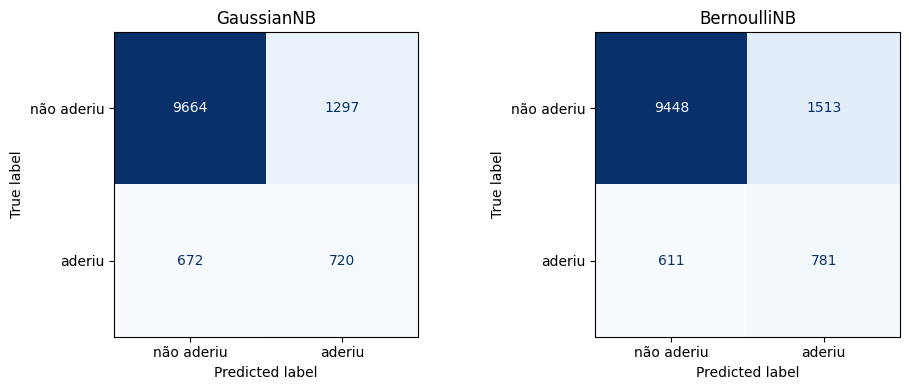

In [79]:
# Matrizes dos dois modelos
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cm_bnb = confusion_matrix(y_test, y_pred_bnb)

# Configurar figura com 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot GaussianNB
disp_gnb = ConfusionMatrixDisplay(cm_gnb, display_labels=["não aderiu", "aderiu"])
disp_gnb.plot(cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title("GaussianNB")

# Plot BernoulliNB
disp_bnb = ConfusionMatrixDisplay(cm_bnb, display_labels=["não aderiu", "aderiu"])
disp_bnb.plot(cmap="Blues", colorbar=False, ax=axes[1])
axes[1].set_title("BernoulliNB")

plt.tight_layout()
plt.show()

### Regressão Logística

In [80]:
# 1. Pipeline unificado com a preparação de dados previamente definida
pipeline_lr = Pipeline([
    ('preparacao', preparacao),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Grade para escolha do parâmetro de regularização C
# Valores menores de C indicam maior força de regularização L2
param_grid_lr = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# 3. Validação cruzada estratificada em 5 dobras
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=cv_stratified,
    scoring='roc_auc',
    n_jobs=-1
)

# Execução da busca no conjunto de treino
grid_lr.fit(X_train, y_train)

best_C = grid_lr.best_params_['logreg__C']
print(f"Melhor parâmetro C encontrado: {best_C}")
print(f"Melhor ROC-AUC na Validação Cruzada: {grid_lr.best_score_:.4f}")

Melhor parâmetro C encontrado: 0.1
Melhor ROC-AUC na Validação Cruzada: 0.7881


=== DESEMPENHO REGRESSÃO LOGÍSTICA NO TESTE ===
Acurácia: 0.8995
ROC-AUC:  0.8034

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95     10961
           1       0.67      0.21      0.32      1392

    accuracy                           0.90     12353
   macro avg       0.79      0.60      0.63     12353
weighted avg       0.88      0.90      0.88     12353



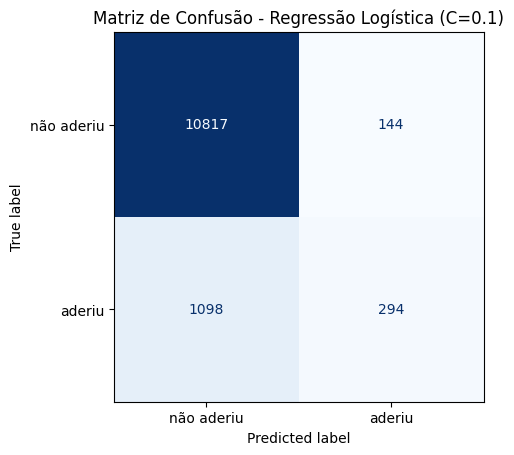

In [81]:
# 1. Recuperar o melhor modelo treinado sobre o conjunto completo de treino
modelo_lr_final = grid_lr.best_estimator_

# 2. Predições e probabilidades no conjunto de teste
y_pred_lr = modelo_lr_final.predict(X_test)
y_proba_lr = modelo_lr_final.predict_proba(X_test)[:, 1]

# 3. Métricas globais de desempenho
print("=== DESEMPENHO REGRESSÃO LOGÍSTICA NO TESTE ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_lr):.4f}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_lr))

# 4. Exibição da Matriz de Confusão
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=["não aderiu", "aderiu"])
disp.plot(cmap="Blues", colorbar=False)
plt.title(f"Matriz de Confusão - Regressão Logística (C={best_C})")
plt.show()

In [82]:

# Nomes dos atributos após as transformações (numéricas + One-Hot Encoding)
feature_names_cat = modelo_lr_final.named_steps['preparacao'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(feature_names_cat)

# Extração dos coeficientes do modelo logístico
coefs = modelo_lr_final.named_steps['logreg'].coef_[0]

# Construção do DataFrame com nomes de colunas em texto limpo
df_coefs = pd.DataFrame({
    'Atributo': all_feature_names,
    'Coeficiente': coefs,
    'Magnitude_Absoluta': np.abs(coefs),
    'Odds_Ratio': np.exp(coefs)
}).sort_values(by='Magnitude_Absoluta', ascending=False)

print("=== TOP 5 COEFICIENTES DE MAIOR MAGNITUDE ===")
display(df_coefs.head(5))

=== TOP 5 COEFICIENTES DE MAIOR MAGNITUDE ===


,Atributo,Coeficiente,Magnitude_Absoluta,Odds_Ratio
3,taxa_variacao_emprego,-1.233284,1.233284,0.291334
43,mes_mar,1.025777,1.025777,2.789261
37,meio_contato_telefone_fixo,-0.622734,0.622734,0.536476
4,indice_precos_consumidor,0.582826,0.582826,1.791093
42,mes_mai,-0.506383,0.506383,0.602672


taxa_variacao_emprego, meio_contato_telefone_fixo e mes_mai têm coeficientes negativos; mes_mar e indice_precos_consumidor, positivos.

Assim, o modelo associa os primeiros a menores chances de adesão e os últimos a maiores chances. Telefone fixo é comparado a celular, e março e maio são comparados a abril. Essas associações não demonstram causalidade.

## 4. Cenários de avaliação


---



Consideramos que, ao escolher quem ligar, o banco já definiu o dia e o canal da chamada e sabe qual será o número dessa tentativa na campanha. Por isso, mantemos esses atributos no cenário principal. Excluímos a duração, que só é conhecida depois da ligação.

In [83]:
# Dois cenários de avaliação -> a mesma divisão de clientes em amboos
X_completo = df_cenario_completo.drop(columns=['aderiu'])

X_train_completo = X_completo.loc[X_train.index]
X_test_completo = X_completo.loc[X_test.index]

In [84]:
# Identifica as colunas numéricas e categóricas do cenário completo
num_cols_completo = X_train_completo.select_dtypes(
    include=[np.number]
).columns.tolist()

cat_cols_completo = X_train_completo.select_dtypes(
    exclude=[np.number]
).columns.tolist()

# A preparação é ajustada somente com os dados de treino
preparacao_completo = ColumnTransformer([
    ('num', Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escala', StandardScaler())
    ]), num_cols_completo),

    ('cat', Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]), cat_cols_completo)
])

In [85]:
# k-NN no cenário completo, com os parâmetros escolhidos no treino.
modelo_knn_completo = Pipeline([
    ('preparacao', preparacao_completo),
    ('knn', KNeighborsClassifier(
        n_neighbors=melhor_k,
        weights=melhor_peso
    ))
])

modelo_knn_completo.fit(X_train_completo, y_train)

y_pred_knn_completo = modelo_knn_completo.predict(X_test_completo)
y_proba_knn_completo = modelo_knn_completo.predict_proba(X_test_completo)[:, 1]

In [86]:
# Naive Bayes no cenário completo, mantendo a mesma variante.
modelo_bnb_completo = Pipeline([
    ('preparacao', preparacao_completo),
    ('bnb', BernoulliNB(binarize=0.0))
])

modelo_bnb_completo.fit(X_train_completo, y_train)

y_pred_bnb_completo = modelo_bnb_completo.predict(X_test_completo)
y_proba_bnb_completo = modelo_bnb_completo.predict_proba(X_test_completo)[:, 1]

In [87]:
# Regressão logística no cenário completo, mantendo o C escolhido no treino.
modelo_lr_completo = Pipeline([
    ('preparacao', preparacao_completo),
    ('logreg', LogisticRegression(
        C=best_C,
        max_iter=1000,
        random_state=42
    ))
])

modelo_lr_completo.fit(X_train_completo, y_train)

y_pred_lr_completo = modelo_lr_completo.predict(X_test_completo)
y_proba_lr_completo = modelo_lr_completo.predict_proba(X_test_completo)[:, 1]

In [88]:
# Tabelinha bonitinha para comparar os resultados dos três modelos nos dois cenários.
comparacao_44 = pd.DataFrame({
    'Modelo': [
        'k-NN', 'k-NN',
        'Naive Bayes', 'Naive Bayes',
        'Regressão logística', 'Regressão logística'
    ],
    'Cenário': [
        'Principal', 'Completo',
        'Principal', 'Completo',
        'Principal', 'Completo'
    ],
    'Acurácia': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_knn_completo),
        accuracy_score(y_test, y_pred_bnb),
        accuracy_score(y_test, y_pred_bnb_completo),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lr_completo)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_knn),
        roc_auc_score(y_test, y_proba_knn_completo),
        roc_auc_score(y_test, y_proba_bnb),
        roc_auc_score(y_test, y_proba_bnb_completo),
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_lr_completo)
    ]
})

display(comparacao_44.round(4))

,Modelo,Cenário,Acurácia,ROC-AUC
0,k-NN,Principal,0.8990,0.7823
1,k-NN,Completo,0.9084,0.9236
2,Naive Bayes,Principal,0.8281,0.7786
3,Naive Bayes,Completo,0.8403,0.8306
4,Regressão logística,Principal,0.8995,0.8034
5,Regressão logística,Completo,0.9099,0.9366


A inclusão da duração da ligação elevou a ROC-AUC dos três modelos:
- k-NN de 0,7823 para 0,9236
- Naive Bayes de 0,7786 para 0,8306
- regressão logística de 0,8034 para 0,9366

Mas esse ganho não ajudaria o banco a escolher quem ligar: antes da chamada, ninguém sabe quanto tempo ela vai durar. Se usássemos essa informação no cenário principal, o resultado pareceria melhor do que o modelo conseguiria entregar na prática. Por isso, deixamos a duração apenas no cenário completo, para comparação.

## 5. Avaliação


---



Como a adesão representa apenas 11,27% da base, a acurácia sozinha não mostra bem quantos clientes interessados o modelo deixa passar. Vamos usar o recall da classe 1 (“sim”) como principal critério de comparação, pois consideramos mais custoso deixar de contatar alguém que aceitaria a oferta. A precisão e as matrizes de confusão ajudam a verificar quantas ligações sem adesão acompanham essa escolha.

In [89]:
# Validação cruzada apenas no treino do cenário principal.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_principal = {
    'k-NN': modelo_knn_final,
    'Naive Bayes': modelo_bnb,
    'Regressão logística': modelo_lr_final
}

resultados_cv = {}

for nome, modelo in modelos_principal.items():
    scores = cross_val_score(
        modelo, X_train, y_train,
        cv=cv, scoring='recall'
    )

    resultados_cv[nome] = {
        'Média': scores.mean(),
        'Desvio': scores.std()
    }

In [90]:
# Previsões dos três modelos nos dois cenários.
casos = [
    ('k-NN', 'Principal', y_pred_knn, y_proba_knn),
    ('Naive Bayes', 'Principal', y_pred_bnb, y_proba_bnb),
    ('Regressão logística', 'Principal', y_pred_lr, y_proba_lr),
    ('k-NN', 'Completo', y_pred_knn_completo, y_proba_knn_completo),
    ('Naive Bayes', 'Completo', y_pred_bnb_completo, y_proba_bnb_completo),
    ('Regressão logística', 'Completo', y_pred_lr_completo, y_proba_lr_completo)
]

linhas = []

for nome, cenario, y_prev, y_prob in casos:
    if cenario == 'Principal':
        media_cv = resultados_cv[nome]['Média']
        desvio_cv = resultados_cv[nome]['Desvio']
    else:
        media_cv = np.nan
        desvio_cv = np.nan

    linhas.append({
        'Modelo': nome,
        'Cenário': cenario,
        'Acurácia': accuracy_score(y_test, y_prev),
        'Precisão 0': precision_score(y_test, y_prev, pos_label=0, zero_division=0),
        'Recall 0': recall_score(y_test, y_prev, pos_label=0, zero_division=0),
        'F1 0': f1_score(y_test, y_prev, pos_label=0, zero_division=0),
        'Precisão 1': precision_score(y_test, y_prev, pos_label=1, zero_division=0),
        'Recall 1': recall_score(y_test, y_prev, pos_label=1, zero_division=0),
        'F1 1': f1_score(y_test, y_prev, pos_label=1, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Recall CV (média)': media_cv,
        'Recall CV (desvio)': desvio_cv
    })

tabela_45 = pd.DataFrame(linhas)
display(tabela_45.round(4))

,Modelo,Cenário,Acurácia,Precisão 0,Recall 0,F1 0,Precisão 1,Recall 1,F1 1,ROC-AUC,Recall CV (média),Recall CV (desvio)
0,k-NN,Principal,0.8990,0.9106,0.9826,0.9452,0.6369,0.2407,0.3493,0.7823,0.2547,0.0156
1,Naive Bayes,Principal,0.8281,0.9393,0.8620,0.8990,0.3405,0.5611,0.4238,0.7786,0.5316,0.0078
2,Regressão logística,Principal,0.8995,0.9078,0.9869,0.9457,0.6712,0.2112,0.3213,0.8034,0.2298,0.0172
3,k-NN,Completo,0.9084,0.9273,0.9731,0.9497,0.6533,0.3994,0.4958,0.9236,NaN,NaN
4,Naive Bayes,Completo,0.8403,0.9428,0.8729,0.9065,0.3683,0.5833,0.4515,0.8306,NaN,NaN
5,Regressão logística,Completo,0.9099,0.9290,0.9728,0.9504,0.6594,0.4145,0.5090,0.9366,NaN,NaN


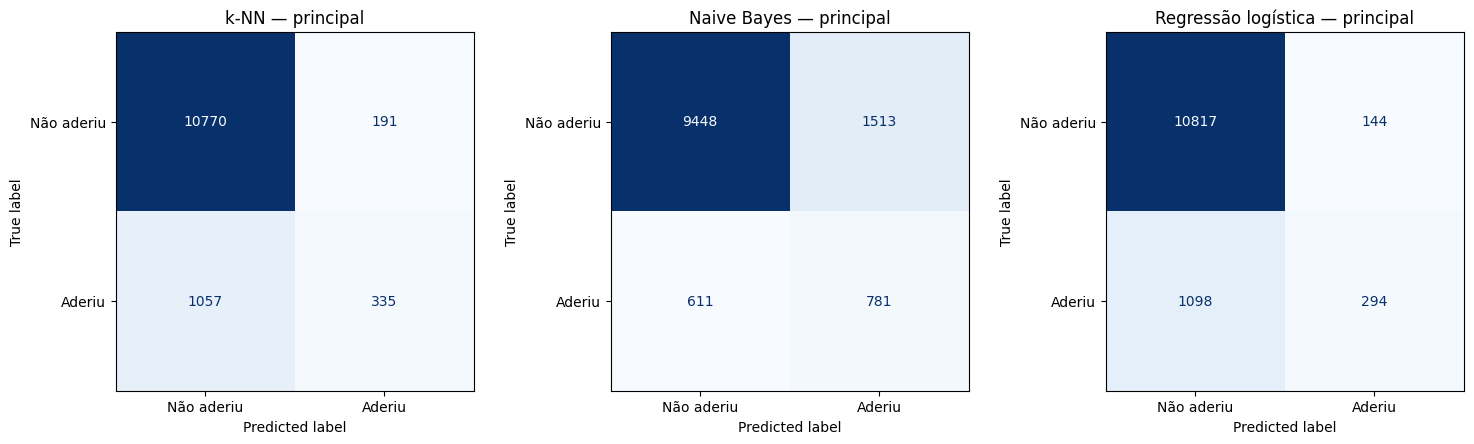

In [91]:
# Matrizes de confusão do cenário principal.
previsoes_principal = {
    'k-NN': y_pred_knn,
    'Naive Bayes': y_pred_bnb,
    'Regressão logística': y_pred_lr
}

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nome, y_prev) in zip(eixos, previsoes_principal.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_prev,
        display_labels=['Não aderiu', 'Aderiu'],
        cmap='Blues',
        colorbar=False,
        ax=ax
    )
    ax.set_title(f'{nome} — principal')

plt.tight_layout()
plt.show()

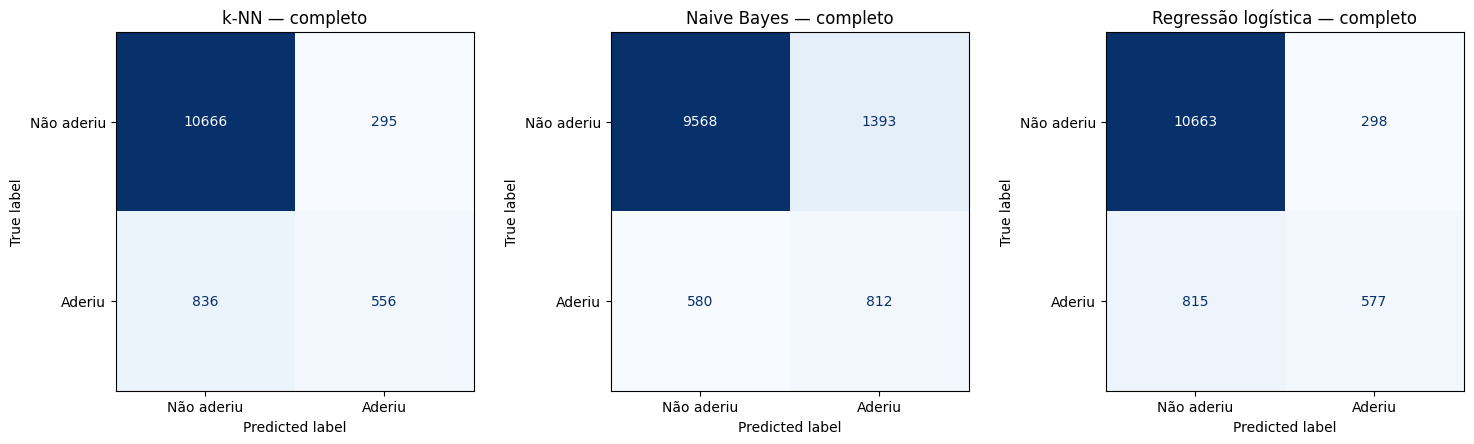

In [92]:
# Matrizes de confusão do cenário completo.
previsoes_completo = {
    'k-NN': y_pred_knn_completo,
    'Naive Bayes': y_pred_bnb_completo,
    'Regressão logística': y_pred_lr_completo
}

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nome, y_prev) in zip(eixos, previsoes_completo.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_prev,
        display_labels=['Não aderiu', 'Aderiu'],
        cmap='Blues',
        colorbar=False,
        ax=ax
    )
    ax.set_title(f'{nome} — completo')

plt.tight_layout()
plt.show()

No cenário principal, o Naive Bayes encontrou 781 dos 1.392 clientes que aderiram: recall de 56,11%, contra 24,07% do k-NN e 21,12% da regressão logística. Ele deixou passar menos interessados, mas também indicou 1.513 clientes que não aderiram — ou seja, exigiria mais ligações. Na validação cruzada, seu recall médio foi de 53,16%, com desvio de 0,78 ponto percentual. Como priorizamos não perder possíveis adesões, ele é nossa escolha entre os modelos utilizáveis antes da ligação, reconhecendo esse custo adicional.